#Aplicação Estatística a problemas reais da Biologia

## Curvas de Crescimento

O crescimento microbiano segue um padrão sigmoidal bem caracterizado, com fases distintas: **lag**, **exponencial**, **estacionária** e **declínio**. A análise quantitativa destas curvas permite extrair parâmetros biológicos que descrevem o comportamento de cada cultura.

---

### Parâmetros-chave

| Parâmetro | Símbolo | Significado biológico |
|---|---|---|
| Plateau | **A** | Densidade ótica máxima atingida (capacidade de carga) |
| Taxa de crescimento máxima | **μ_max** | Inclinação máxima da curva — quão rápido as células se dividem |
| Fase lag | **λ** | Tempo que a cultura demora a iniciar o crescimento exponencial |

---


In [1]:
# Importar Pacotes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# FASE 1 — Carregar e visualizar os dados
1. Olhando para os dados conseguem responder às seguintes perguntas: 
   1. **"Qual o micróbio que demora mais tempo a iniciar o crescimento?"**
   2. **"Qual o micróbio que demora mais tempo a iniciar o crescimento?"** → Comparar **λ**
   3. **"Qual o micróbio que consegue atingir a maior densidade?"**  → Comparar **A**
   4. **"Qual o micróbio cresce mais rápido?"** → Comparar **μ_max**

In [2]:
# Carregar o CSV
df = pd.read_csv("crescimento_microbiano.csv", sep=';')

print("Primeiras linhas do DataFrame:")
print(df.head(5))

print(df['Strain'].unique()) 

print("\nEstatísticas descritivas:")
print(df.describe().round(3))


Primeiras linhas do DataFrame:
                Strain Replicate      0      1      2      3      4      5  \
0           E_coli_K12        R1  0.074  0.239  1.974  2.752  2.829  2.848   
1           E_coli_K12        R2  0.000  0.194  1.860  2.638  2.788  2.769   
2           E_coli_K12        R3  0.000  0.131  1.807  2.582  2.720  2.784   
3  Salmonella_enterica        R1  0.000  0.009  0.821  2.061  2.504  2.570   
4  Salmonella_enterica        R2  0.000  0.000  0.822  2.088  2.472  2.589   

       6      7  ...     10     11     12     13     14     16     18     20  \
0  2.906  2.882  ...  2.845  2.845  2.866  2.801  2.807  2.842  2.828  2.868   
1  2.818  2.789  ...  2.862  2.806  2.775  2.832  2.770  2.813  2.748  2.767   
2  2.766  2.703  ...  2.735  2.774  2.787  2.784  2.731  2.746  2.766  2.785   
3  2.556  2.589  ...  2.626  2.501  2.604  2.582  2.570  2.582  2.520  2.573   
4  2.593  2.622  ...  2.582  2.550  2.602  2.601  2.594  2.587  2.551  2.581   

      22     24  
0

# FASE 2 — Estimar os parâmetros de crescimento e representar graficamente

Cada grupo vai analisar um microorganismo diferente. 
Altere a variável abaixo para a estirpe que vão analisar:
    - Grupo 1: E_coli_K12, 
    - Grupo 2: Salmonella_enterica, 
    - Grupo 3: L_acidophilus,
    - Grupo 4: C_difficile, 
    - Grupo 5: S_cerevisiae, 
    - Grupo 6: C_albicans.

1. Filtrar a dataframe para os valores a utilizar

In [3]:
estirpe = "E_coli_K12" # defina a estirpe a analisar

# Filtrar réplicas do microorganimo escolhido
df_estirpe = df[df["Strain"] == estirpe] # filtrar o dataframe para a estirpe escolhida

# Filtrar a dataframe para as colunas com dados apenas
columns = df.columns.to_list() # lista o nome das colunas do dataframe
time_cols = columns[2:]  # mantém apenas as colunas de tempo (assumindo que as 2 primeiras são 'Strain' e 'Replicate')
df_estirpe_time = df_estirpe[time_cols] # criar dataframe apenas com as colunas de tempo para a estirpe escolhida
print(f"DataFrame filtrado para a estirpe {estirpe}:\n{df_estirpe_time.head(5)}")

DataFrame filtrado para a estirpe E_coli_K12:
       0      1      2      3      4      5      6      7      8      9  \
0  0.074  0.239  1.974  2.752  2.829  2.848  2.906  2.882  2.845  2.875   
1  0.000  0.194  1.860  2.638  2.788  2.769  2.818  2.789  2.798  2.789   
2  0.000  0.131  1.807  2.582  2.720  2.784  2.766  2.703  2.765  2.744   

      10     11     12     13     14     16     18     20     22     24  
0  2.845  2.845  2.866  2.801  2.807  2.842  2.828  2.868  2.831  2.816  
1  2.862  2.806  2.775  2.832  2.770  2.813  2.748  2.767  2.813  2.829  
2  2.735  2.774  2.787  2.784  2.731  2.746  2.766  2.785  2.741  2.750  


2. Estimar o valor médio e desvio padrão das diferentes réplicas e criar arrays com os dados.

In [4]:
od_mean = df_estirpe_time.mean().values # calcular média para cada tempo
print(f"Médias calculadas por cada periodo de tempo analisado:\n{od_mean}")
od_std  = df_estirpe_time.std().values # calcular desvio-padrão para cada tempo
print(f"Desvios-padrão:\n{od_std}")
time_array = np.array(time_cols, dtype=float) # criar array de tempos a partir dos nomes das colunas
print(f"Array de tempos (horas): {time_array}")

Médias calculadas por cada periodo de tempo analisado:
[0.02466667 0.188      1.88033333 2.65733333 2.779      2.80033333
 2.83       2.79133333 2.80266667 2.80266667 2.814      2.80833333
 2.80933333 2.80566667 2.76933333 2.80033333 2.78066667 2.80666667
 2.795      2.79833333]
Desvios-padrão:
[0.04272392 0.05424942 0.08533659 0.08663333 0.05505452 0.04195633
 0.07076722 0.08952281 0.04020365 0.06656075 0.068942   0.03555747
 0.0494402  0.0243379  0.03800439 0.04923752 0.04196824 0.05387331
 0.04762352 0.04235957]
Array de tempos (horas): [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 16. 18. 20.
 22. 24.]


3. Faz o gráfico dos dados

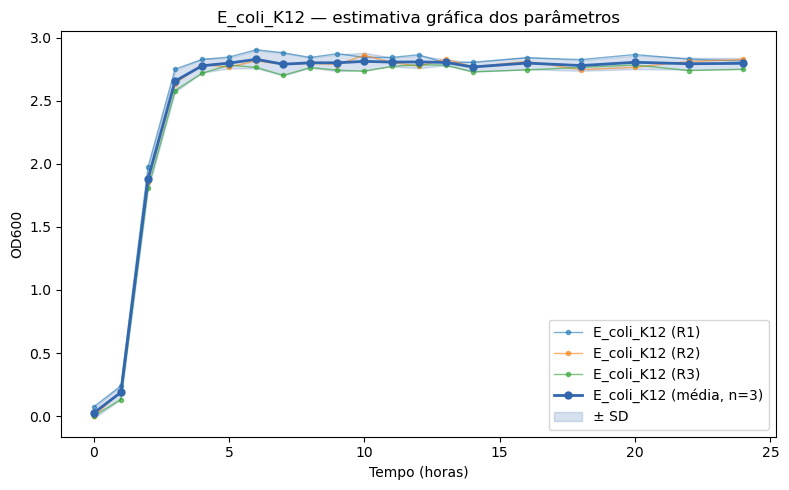

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

# Réplicas individuais
for _, row in df_estirpe_time.iterrows():
    od_rep = row.values.astype(float)
    rep    = df_estirpe.loc[_, "Replicate"]
    ax.plot(time_array, od_rep, "o-", linewidth=1, markersize=3,
            alpha=0.6, label=f"{estirpe} ({rep})")

# Curva média
ax.plot(time_array, od_mean, "o-", color="#3266ad", linewidth=2,
        markersize=5, label=f"{estirpe} (média, n={len(df_estirpe)})")

# Banda de desvio padrão
ax.fill_between(time_array, od_mean - od_std, od_mean + od_std,
                color="#3266ad", alpha=0.2, label="± SD")

ax.set_xlabel("Tempo (horas)")
ax.set_ylabel("OD600")
ax.set_title(f"{estirpe} — estimativa gráfica dos parâmetros")
ax.legend()
plt.tight_layout()
display(fig)
plt.close()

4. Estímativa de parâmetros de crescimento.

4.1. Crescimento Máximo.


$$A = \frac{1}{n}\sum_{i=k}^{n} OD_i \quad \text{(média dos últimos pontos)}$$


  R1: Plateau ≈ 2.847
  R2: Plateau ≈ 2.801
  R3: Plateau ≈ 2.756

Estimativas gráficas para E_coli_K12:
  Plateau (A) média ≈ 2.801


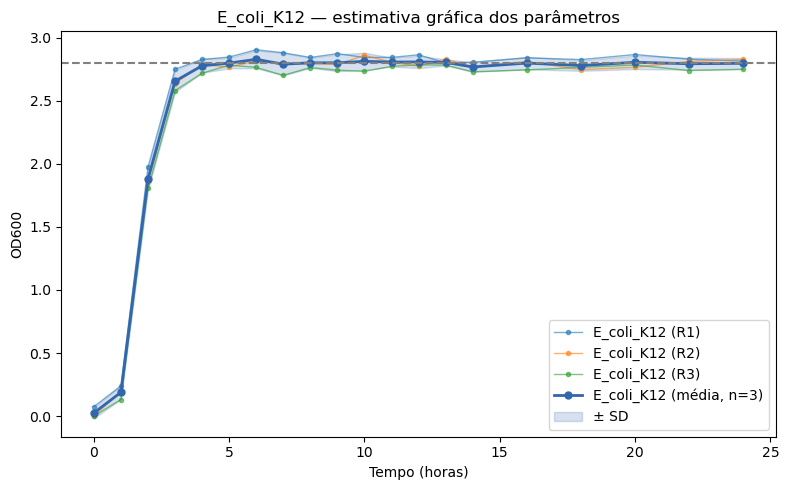

In [6]:
# ── Plateau (A) ─────────────────────────────────────────
valores_A = od_mean[6:] # selecionar os valores a partir do tempo onde a curva parece estabilizar (usar o array de médias)
A_estimado = valores_A.mean() # calcular a média dos valores para obter a estimativa do plateau

# calcular o plateau para cada réplica individualmente
for _, row in df_estirpe_time.iterrows():
    od_rep = row.values.astype(float) # extrair os valores de OD da réplica
    A_rep  = od_rep[6:].mean() # calcular o plateau da réplica
    print(f"  {df_estirpe.loc[_, 'Replicate']}: Plateau ≈ {A_rep:.3f}")

ax.axhline(A_estimado, color="gray", linestyle="--", label=f"Plateau ≈ {A_estimado:.2f}") # representar graficamente

print(f"\nEstimativas gráficas para {estirpe}:")
print(f"  Plateau (A) média ≈ {A_estimado:.3f}")
display(fig)
plt.close()

4.2 Taxa de Crescimento

$$\mu_{max} = \max\left(\frac{\Delta OD}{\Delta t}\right) = \max\left(\frac{OD_{i+1} - OD_i}{t_{i+1} - t_i}\right)$$

Valores de OD para crescimento exponencial: [0.02466667 0.188      1.88033333 2.65733333]
Tempos correspondentes: [0. 1. 2. 3.]
Taxa de crescimento (ΔOD): [0.16333333 1.69233333 0.777     ]
Intervalos de tempo (Δt): [1. 1. 1.]
Taxa de crescimento por hora (ΔOD/Δt): [0.16333333 1.69233333 0.777     ]
  R1: μ_max ≈ 1.735 OD/h
  R2: μ_max ≈ 1.666 OD/h
  R3: μ_max ≈ 1.676 OD/h
O crescimento máximo de 1.692 OD/h ocorre no tempo de 1.0 horas

────────────────────────────────────────
Estimativas gráficas para E_coli_K12:
  Plateau (A)  ≈ 2.801
  μ_max        ≈ 1.692 OD/h
────────────────────────────────────────


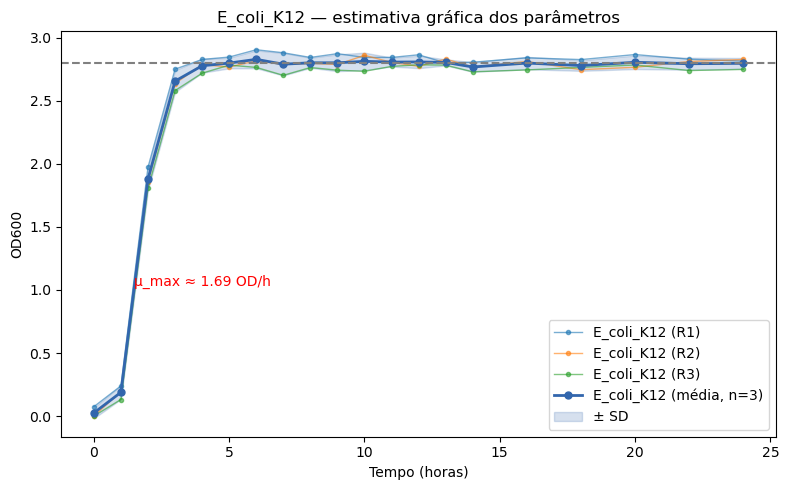

In [7]:
# ── Taxa máxima (mu) ────────────────────────────────────
values_umax = od_mean[0:4] # selecionar os valores de OD para os tempos de crescimento exponencial
print(f"Valores de OD para crescimento exponencial: {values_umax}")
time_umax = time_array[0:4] # selecionar os tempos correspondentes aos valores de OD
print(f"Tempos correspondentes: {time_umax}")
dod = np.diff(values_umax) # calcular a diferença entre os valores de OD para obter a taxa de crescimento
print(f"Taxa de crescimento (ΔOD): {dod}")
dt = np.diff(time_umax) # calcular intervalo de tempo
print(f"Intervalos de tempo (Δt): {dt}")
dod_dt = dod / dt # aplicar a fórmula da taxa de crescimento (ΔOD/Δt)
print(f"Taxa de crescimento por hora (ΔOD/Δt): {dod_dt}")

# calcular mu para cada réplica individualmente
for _, row in df_estirpe_time.iterrows():
    od_rep      = row.values.astype(float) # extrair os valores de OD da réplica
    dod_dt_rep  = np.diff(od_rep[0:4]) / np.diff(time_umax) # calcular a taxa de crescimento da réplica
    mu_rep      = np.max(dod_dt_rep) # estimar μ_max da réplica
    print(f"  {df_estirpe.loc[_, 'Replicate']}: μ_max ≈ {mu_rep:.3f} OD/h")

mu_estimado  = np.max(dod_dt) # encontrar the maximum value of the growth rate to estimate μ_max
idx_max      = np.argmax(dod_dt) # encontrar o índice no array no valor máximo
time_mu_max  = time_umax[idx_max] # para identificar o tempo correspondente
print(f"O crescimento máximo de {mu_estimado:.3f} OD/h ocorre no tempo de {time_mu_max} horas")

ax.annotate(f"μ_max ≈ {mu_estimado:.2f} OD/h",
            xy=(time_umax[idx_max], od_mean[idx_max+1]),
            xytext=((time_array[idx_max] + time_array[idx_max + 1]) / 2, (od_mean[idx_max] + od_mean[idx_max + 1]) / 2),
            color="red", fontsize=10)

print(f"\n{'─'*40}")
print(f"Estimativas gráficas para {estirpe}:")
print(f"  Plateau (A)  ≈ {A_estimado:.3f}")
print(f"  μ_max        ≈ {mu_estimado:.3f} OD/h")
print(f"{'─'*40}")
display(fig)
plt.close()

4.3 Fase de Lag (lambda):
$$\lambda = t_{inf} - \frac{OD_{inf} - OD_0}{\mu_{max}}$$

  R1: Lag ≈ 1.000 h
  R2: Lag ≈ 1.000 h
  R3: Lag ≈ 1.000 h

────────────────────────────────────────
Estimativas gráficas para E_coli_K12:
  Plateau (A)  ≈ 2.801
  μ_max        ≈ 1.692 OD/h
  Fase lag     ≈ 1.0 h
────────────────────────────────────────


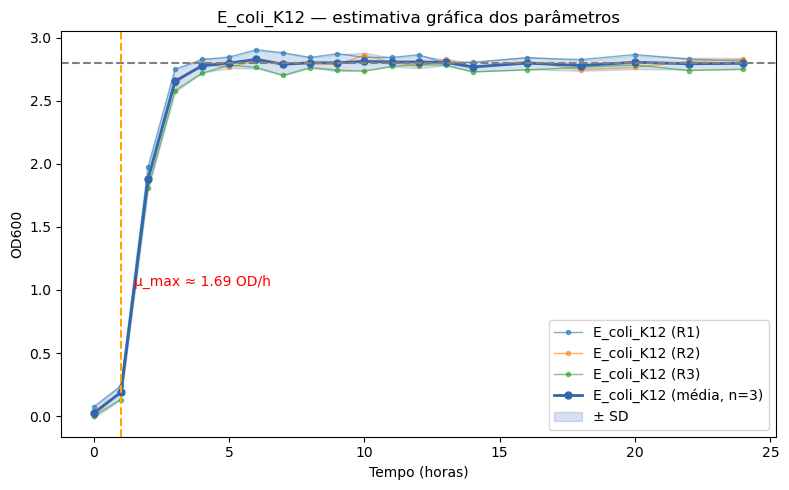

In [8]:
threshold = od_mean[0] + 0.1 # OD inicial + margem para ignorar ruído
lam_estimado = time_array[od_mean > threshold][0] # primeiro tempo onde OD ultrapassa o threshold

# calcular lam para cada réplica individualmente
for _, row in df_estirpe_time.iterrows():
    od_rep  = row.values.astype(float) # extrair os valores de OD da réplica
    lam_rep = time_array[od_rep > od_rep[0] + 0.1][0] # primeiro tempo onde OD ultrapassa o threshold
    print(f"  {df_estirpe.loc[_, 'Replicate']}: Lag ≈ {lam_rep:.3f} h")

ax.axvline(lam_estimado, color="orange", linestyle="--", label=f"Lag ≈ {lam_estimado:.1f}h") # representar graficamente

print(f"\n{'─'*40}")
print(f"Estimativas gráficas para {estirpe}:")
print(f"  Plateau (A)  ≈ {A_estimado:.3f}")
print(f"  μ_max        ≈ {mu_estimado:.3f} OD/h")
print(f"  Fase lag     ≈ {lam_estimado:.1f} h")
print(f"{'─'*40}")
display(fig)
plt.close()

In [9]:
resultados = []

time_cols  = [c for c in df.columns if c not in ["Strain", "Replicate"]]
time_array = np.array(time_cols, dtype=float)


def calcular_parametros(t, od):
    # Plateau — média dos últimos 20% dos pontos
    n_plateau = max(3, int(0.2 * len(od)))
    A = od[-n_plateau:].mean()

    # Derivada numérica (diferenças finitas)
    dod_dt = np.diff(od) / np.diff(t)
    t_mid  = (t[:-1] + t[1:]) / 2

    # mu_max — valor máximo da derivada
    idx_max = np.argmax(dod_dt)
    mu      = dod_dt[idx_max]

    # Fase lag — threshold
    threshold = od[0] + 0.1
    lam = t[od > threshold][0]

    return {"A": round(A, 3), "mu": round(mu, 3), "lam": round(lam, 3)}


for estirpe in df["Strain"].unique():
    df_estirpe = df[df["Strain"] == estirpe]
    df_estirpe_time = df_estirpe[time_cols]

    for _, row in df_estirpe_time.iterrows():
        od_rep = row.values.astype(float)
        params = calcular_parametros(time_array, od_rep)
        params["Strain"]    = estirpe
        params["Replicate"] = df_estirpe.loc[_, "Replicate"]
        resultados.append(params)

df_params = pd.DataFrame(resultados).set_index(["Strain", "Replicate"])

df_resumo = df_params.groupby("Strain").agg(
    A_mean=("A", "mean"), A_sd=("A", "std"),
    mu_mean=("mu", "mean"), mu_sd=("mu", "std"),
    lam_mean=("lam", "mean"), lam_sd=("lam", "std")
).round(3)

print("Parâmetros por réplica:")
print(df_params.to_string())
print("\nResumo (média ± SD por estirpe):")
print(df_resumo.to_string())

Parâmetros por réplica:
                                   A     mu  lam
Strain              Replicate                   
E_coli_K12          R1         2.836  1.735  1.0
                    R2         2.789  1.666  1.0
                    R3         2.760  1.676  1.0
Salmonella_enterica R1         2.577  1.240  2.0
                    R2         2.571  1.266  2.0
                    R3         2.685  1.286  2.0
L_acidophilus       R1         1.948  0.619  4.0
                    R2         2.086  0.540  4.0
                    R3         1.973  0.583  4.0
C_difficile         R1         2.258  0.498  4.0
                    R2         2.062  0.445  5.0
                    R3         2.138  0.557  4.0
S_cerevisiae        R1         2.334  0.352  5.0
                    R2         2.310  0.356  5.0
                    R3         2.361  0.379  5.0
C_albicans          R1         1.767  0.310  6.0
                    R2         1.774  0.269  6.0
                    R3         1.808  0.267  

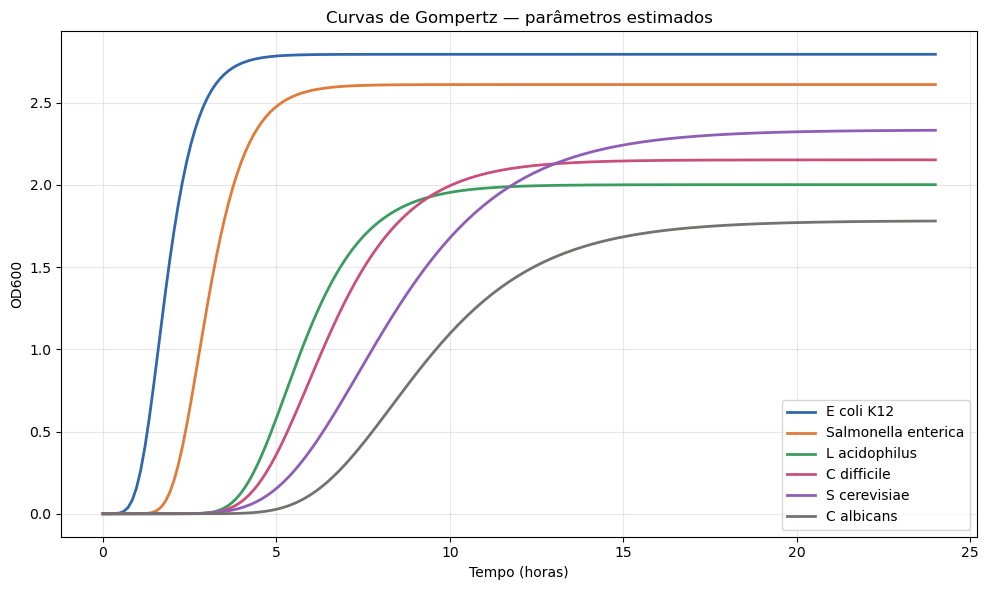

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

def gompertz(t, A, mu, lam):
    return A * np.exp(-np.exp((mu * np.e / A) * (lam - t) + 1))

cores = ["#3266ad", "#e07b39", "#3a9c5f", "#c94f7c", "#8e5db5", "#73726c"]

t_curva = np.linspace(0, time_array[-1], 200)

for estirpe, cor in zip(df["Strain"].unique(), cores):
    params   = df_resumo.loc[estirpe]
    od_curva = gompertz(t_curva, params["A_mean"], params["mu_mean"], params["lam_mean"])
    ax.plot(t_curva, od_curva, color=cor, linewidth=2, label=estirpe.replace("_", " "))

ax.set_xlabel("Tempo (horas)")
ax.set_ylabel("OD600")
ax.set_title("Curvas de Gompertz — parâmetros estimados")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

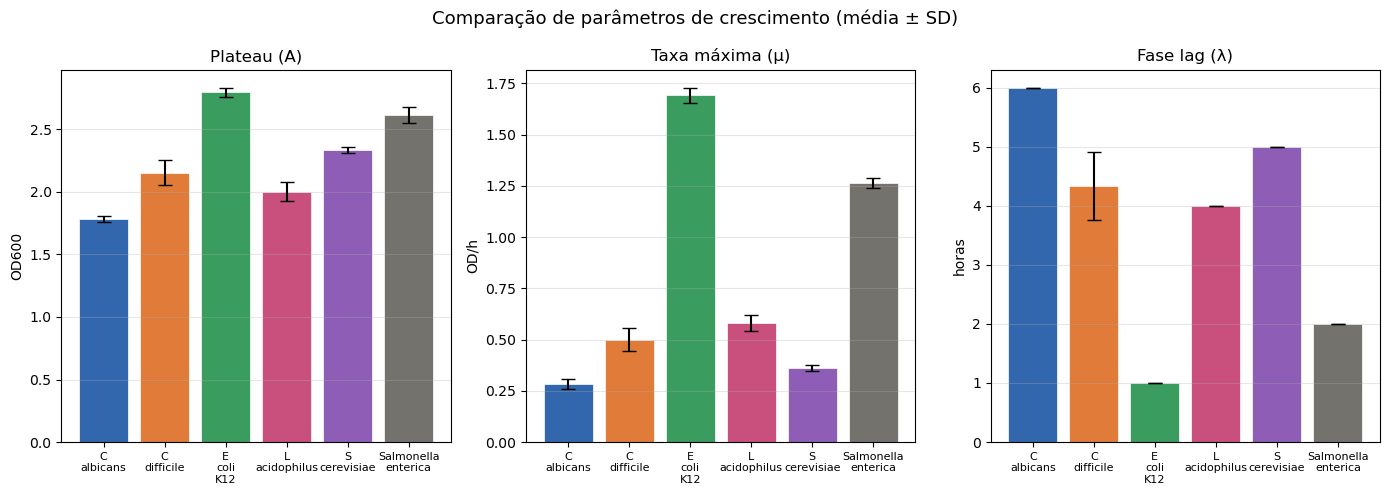

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

params_plot = [
    ("A_mean",   "A_sd",   "Plateau (A)",    "OD600"),
    ("mu_mean",  "mu_sd",  "Taxa máxima (µ)", "OD/h"),
    ("lam_mean", "lam_sd", "Fase lag (λ)",    "horas"),
]

cores = ["#3266ad", "#e07b39", "#3a9c5f", "#c94f7c", "#8e5db5", "#73726c"]
estirpes = df_resumo.index.tolist()

for ax, (mean_col, sd_col, titulo, unidade) in zip(axes, params_plot):
    valores = df_resumo[mean_col].values
    erros   = df_resumo[sd_col].values

    bars = ax.bar(range(len(estirpes)), valores, yerr=erros,
                  color=cores, capsize=5, edgecolor="white", linewidth=0.5)

    ax.set_xticks(range(len(estirpes)))
    ax.set_xticklabels([e.replace("_", "\n") for e in estirpes], fontsize=8)
    ax.set_title(titulo)
    ax.set_ylabel(unidade)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Comparação de parâmetros de crescimento (média ± SD)", fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ── Definir grupos ───────────────────────────────────────
bacterias        = ["E_coli_K12", "Salmonella_enterica", "L_acidophilus", "C_difficile"]
leveduras        = ["S_cerevisiae", "C_albicans"]

# ── Estatística por parâmetro ────────────────────────────
for param, titulo in [("A", "Plateau (A)"), ("mu", "Taxa máxima (µ)"), ("lam", "Fase lag (λ)")]:
    print(f"\n{'═'*55}")
    print(f"{titulo}")
    print(f"{'═'*55}")

    grupos = {e: df_params.loc[e][param].values for e in df_params.index.get_level_values("Strain").unique()}

    # ── ANOVA entre todas as estirpes ────────────────────
    f_stat, p_anova = stats.f_oneway(*grupos.values())
    print(f"\nANOVA (todas as estirpes): F={f_stat:.3f}, p={p_anova:.4f}")

    # ── Tukey HSD post-hoc ───────────────────────────────
    valores = np.concatenate(list(grupos.values()))
    labels  = np.concatenate([[e]*3 for e in grupos.keys()])
    tukey   = pairwise_tukeyhsd(valores, labels, alpha=0.05)
    print("\nTukey HSD:")
    print(tukey.summary())

    # ── Bactérias vs Leveduras ───────────────────────────
    vals_bact = np.concatenate([grupos[e] for e in bacterias])
    vals_lev  = np.concatenate([grupos[e] for e in leveduras])
    t_stat, p_ttest = stats.ttest_ind(vals_bact, vals_lev)
    print(f"\nt-test bactérias vs leveduras: t={t_stat:.3f}, p={p_ttest:.4f}")
    print(f"  bactérias: média={vals_bact.mean():.3f} ± {vals_bact.std():.3f}")
    print(f"  leveduras: média={vals_lev.mean():.3f} ± {vals_lev.std():.3f}")

    # ── Patogénicas vs Comen


═══════════════════════════════════════════════════════
Plateau (A)
═══════════════════════════════════════════════════════

ANOVA (todas as estirpes): F=118.099, p=0.0000

Tukey HSD:
          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
    group1           group2       meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
   C_albicans         C_difficile   0.3697 0.0001   0.204  0.5353   True
   C_albicans          E_coli_K12    1.012    0.0  0.8463  1.1777   True
   C_albicans       L_acidophilus   0.2193  0.008  0.0537   0.385   True
   C_albicans        S_cerevisiae    0.552    0.0  0.3863  0.7177   True
   C_albicans Salmonella_enterica    0.828    0.0  0.6623  0.9937   True
  C_difficile          E_coli_K12   0.6423    0.0  0.4767   0.808   True
  C_difficile       L_acidophilus  -0.1503 0.0837  -0.316  0.0153  False
  C_difficile        S_cerevisiae   0.1823 0.0283  0.0167   0.348   True
  C_difficil

In [13]:
# ── Bactérias patogénicas vs comensais ──────────────────
bact_patogenicas = ["Salmonella_enterica", "C_difficile"]
bact_comensais   = ["E_coli_K12", "L_acidophilus"]

# ── Leveduras patogénicas vs comensais ──────────────────
lev_patogenicas = ["C_albicans"]
lev_comensais   = ["S_cerevisiae"]

for param, titulo in [("A", "Plateau (A)"), ("mu", "Taxa máxima (µ)"), ("lam", "Fase lag (λ)")]:
    print(f"\n{'═'*55}")
    print(f"{titulo}")
    print(f"{'═'*55}")

    grupos = {e: df_params.loc[e][param].values for e in df_params.index.get_level_values("Strain").unique()}

    # ── Bactérias patogénicas vs comensais ───────────────
    vals_bact_pat = np.concatenate([grupos[e] for e in bact_patogenicas])
    vals_bact_com = np.concatenate([grupos[e] for e in bact_comensais])
    t_stat, p_ttest = stats.ttest_ind(vals_bact_pat, vals_bact_com)
    print(f"\nt-test bactérias patogénicas vs comensais: t={t_stat:.3f}, p={p_ttest:.4f}")
    print(f"  patogénicas: média={vals_bact_pat.mean():.3f} ± {vals_bact_pat.std():.3f}")
    print(f"  comensais:   média={vals_bact_com.mean():.3f} ± {vals_bact_com.std():.3f}")

    # ── Leveduras patogénicas vs comensais ───────────────
    vals_lev_pat = np.concatenate([grupos[e] for e in lev_patogenicas])
    vals_lev_com = np.concatenate([grupos[e] for e in lev_comensais])
    t_stat, p_ttest = stats.ttest_ind(vals_lev_pat, vals_lev_com)
    print(f"\nt-test leveduras patogénicas vs comensais: t={t_stat:.3f}, p={p_ttest:.4f}")
    print(f"  patogénicas: média={vals_lev_pat.mean():.3f} ± {vals_lev_pat.std():.3f}")
    print(f"  comensais:   média={vals_lev_com.mean():.3f} ± {vals_lev_com.std():.3f}")


═══════════════════════════════════════════════════════
Plateau (A)
═══════════════════════════════════════════════════════

t-test bactérias patogénicas vs comensais: t=-0.081, p=0.9371
  patogénicas: média=2.382 ± 0.239
  comensais:   média=2.399 ± 0.399

t-test leveduras patogénicas vs comensais: t=-28.417, p=0.0000
  patogénicas: média=1.783 ± 0.018
  comensais:   média=2.335 ± 0.021

═══════════════════════════════════════════════════════
Taxa máxima (µ)
═══════════════════════════════════════════════════════

t-test bactérias patogénicas vs comensais: t=-0.842, p=0.4196
  patogénicas: média=0.882 ± 0.384
  comensais:   média=1.137 ± 0.557

t-test leveduras patogénicas vs comensais: t=-4.915, p=0.0080
  patogénicas: média=0.282 ± 0.020
  comensais:   média=0.362 ± 0.012

═══════════════════════════════════════════════════════
Fase lag (λ)
═══════════════════════════════════════════════════════

t-test bactérias patogénicas vs comensais: t=0.773, p=0.4576
  patogénicas: média=3.16

/opt/conda/envs/pybioinfo/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


## Expressão RT-PCR

*   Normalização (2−ΔΔCt​)
*   t-test
*   ANOVA One-way 3 grupos